# ❤️ Heart Disease Dataset - Exploratory Data Analysis

## Multi-Disease AI Healthcare Platform | BTP 2025-2026

---

### 📋 Notebook Overview

This notebook performs comprehensive Exploratory Data Analysis (EDA) on the **Heart Disease (Cardiovascular) Dataset** to understand data quality, feature distributions, and preprocessing requirements.

### 🎯 Objectives
1. Understand dataset structure and feature types
2. Identify missing values and their patterns
3. Analyze class distribution (disease vs no disease)
4. Detect outliers and anomalies
5. Explore feature correlations
6. Generate preprocessing recommendations for Week 3

### 📊 Dataset Information
- **Source:** Cardiovascular Disease Dataset
- **Size:** ~70,000 patient records
- **Target:** `cardio` (1 = cardiovascular disease, 0 = healthy)
- **Features:** Age, gender, blood pressure, cholesterol, glucose, lifestyle factors

---

**Author:** BTP Project Team  
**Date:** January 27, 2026  
**Week:** 2 - Exploratory Data Analysis

## 1. Setup and Data Loading

In [2]:
# ============================================================================
# IMPORTS AND CONFIGURATION
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

# Add project root to path for imports
import sys
sys.path.insert(0, str(Path.cwd().parent.parent))

# Import our EDA utilities
from src.utils.eda_utils import (
    load_dataset, missing_value_analysis, statistical_summary,
    class_distribution_analysis, distribution_plots, outlier_analysis,
    correlation_analysis, feature_type_analysis, generate_eda_report,
    COLORS
)

# Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

# Paths
DATA_PATH = Path('../../datasets/heart_disease.csv')
FIGURES_PATH = Path('./figures/heart_disease')
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

print("✅ Libraries imported successfully!")
print(f"📁 Data path: {DATA_PATH}")
print(f"📁 Figures will be saved to: {FIGURES_PATH}")

✅ Libraries imported successfully!
📁 Data path: ..\..\datasets\heart_disease.csv
📁 Figures will be saved to: figures\heart_disease


In [3]:
# ============================================================================
# LOAD DATASET
# ============================================================================

df = load_dataset(DATA_PATH)

# Display first few rows
print("\n📋 First 5 rows of the dataset:")
df.head()

📊 DATASET OVERVIEW
📁 File: heart_disease.csv
📐 Shape: 70,000 rows × 13 columns
💾 Memory Usage: 6.94 MB
🔢 Numeric Columns: 13
📝 Categorical Columns: 0

📋 First 5 rows of the dataset:


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.000,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.000,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.000,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.000,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.000,100,60,1,1,0,0,0,0


In [4]:
# ============================================================================
# COLUMN INFORMATION
# ============================================================================

print("📋 COLUMN DESCRIPTIONS")
print("=" * 70)

column_descriptions = {
    'id': 'Patient ID (unique identifier)',
    'age': 'Age in DAYS (needs conversion to years)',
    'gender': 'Gender (1 = Female, 2 = Male)',
    'height': 'Height in cm',
    'weight': 'Weight in kg',
    'ap_hi': 'Systolic blood pressure (mmHg)',
    'ap_lo': 'Diastolic blood pressure (mmHg)',
    'cholesterol': 'Cholesterol level (1: normal, 2: above normal, 3: well above normal)',
    'gluc': 'Glucose level (1: normal, 2: above normal, 3: well above normal)',
    'smoke': 'Smoking status (0 = No, 1 = Yes)',
    'alco': 'Alcohol consumption (0 = No, 1 = Yes)',
    'active': 'Physical activity (0 = No, 1 = Yes)',
    'cardio': '🎯 TARGET: Cardiovascular disease (0 = No, 1 = Yes)'
}

for col in df.columns:
    desc = column_descriptions.get(col, 'No description available')
    dtype = df[col].dtype
    print(f"• {col:15} ({dtype}): {desc}")

📋 COLUMN DESCRIPTIONS
• id              (int64): Patient ID (unique identifier)
• age             (int64): Age in DAYS (needs conversion to years)
• gender          (int64): Gender (1 = Female, 2 = Male)
• height          (int64): Height in cm
• weight          (float64): Weight in kg
• ap_hi           (int64): Systolic blood pressure (mmHg)
• ap_lo           (int64): Diastolic blood pressure (mmHg)
• cholesterol     (int64): Cholesterol level (1: normal, 2: above normal, 3: well above normal)
• gluc            (int64): Glucose level (1: normal, 2: above normal, 3: well above normal)
• smoke           (int64): Smoking status (0 = No, 1 = Yes)
• alco            (int64): Alcohol consumption (0 = No, 1 = Yes)
• active          (int64): Physical activity (0 = No, 1 = Yes)
• cardio          (int64): 🎯 TARGET: Cardiovascular disease (0 = No, 1 = Yes)


## 2. Data Quality Assessment

In [5]:
# ============================================================================
# DATA TYPES AND INFO
# ============================================================================

print("📊 DATA TYPES AND MEMORY")
print("=" * 50)
print(df.dtypes)
print("\n" + "=" * 50)
print(f"\n💾 Total Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

📊 DATA TYPES AND MEMORY
id               int64
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object


💾 Total Memory Usage: 6.94 MB


In [6]:
# ============================================================================
# MISSING VALUE ANALYSIS
# ============================================================================

missing_stats = missing_value_analysis(df, plot=True, figsize=(14, 5))

# Save figure if needed
# plt.savefig(FIGURES_PATH / 'missing_values.png', dpi=150, bbox_inches='tight')


🔍 MISSING VALUE ANALYSIS
📊 Total Cells: 910,000
❌ Total Missing: 0
📈 Overall Missing Rate: 0.00%
📋 Columns with Missing Values: 0/13

✅ No missing values found in this dataset!


In [7]:
# ============================================================================
# CHECK FOR DUPLICATE RECORDS
# ============================================================================

print("🔍 DUPLICATE ANALYSIS")
print("=" * 50)

# Check duplicates (excluding ID column)
duplicates = df.drop('id', axis=1).duplicated().sum()
dup_pct = (duplicates / len(df)) * 100

print(f"📋 Total Records: {len(df):,}")
print(f"🔄 Duplicate Records: {duplicates:,} ({dup_pct:.2f}%)")

if duplicates > 0:
    print(f"⚠️  Consider removing duplicates during preprocessing.")
else:
    print(f"✅ No duplicate records found.")

🔍 DUPLICATE ANALYSIS
📋 Total Records: 70,000
🔄 Duplicate Records: 24 (0.03%)
⚠️  Consider removing duplicates during preprocessing.


## 3. Feature Engineering Observations

### ⚠️ Important Data Issues Identified:
1. **Age is in DAYS** - needs conversion to years
2. **BMI can be calculated** from height and weight
3. **Blood pressure** may have unrealistic values (data quality issue)

📅 AGE ANALYSIS (Currently in Days)

Age in Days:
   Min: 10,798 days (29.6 years)
   Max: 23,713 days (65.0 years)
   Mean: 19,469 days (53.3 years)

📊 Age Distribution (converted to years):
   Range: 29.6 - 65.0 years


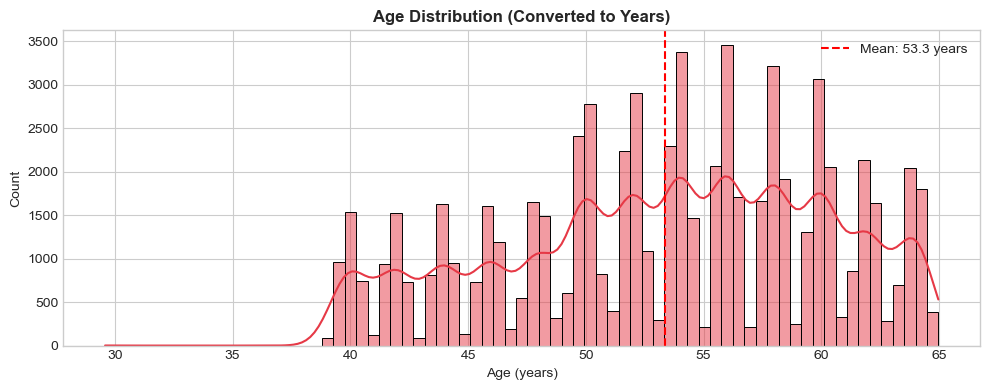

In [8]:
# ============================================================================
# FEATURE ENGINEERING PREVIEW: AGE CONVERSION
# ============================================================================

print("📅 AGE ANALYSIS (Currently in Days)")
print("=" * 50)

# Current age statistics (in days)
print(f"\nAge in Days:")
print(f"   Min: {df['age'].min():,} days ({df['age'].min()/365:.1f} years)")
print(f"   Max: {df['age'].max():,} days ({df['age'].max()/365:.1f} years)")
print(f"   Mean: {df['age'].mean():,.0f} days ({df['age'].mean()/365:.1f} years)")

# Preview age in years
age_years = df['age'] / 365
print(f"\n📊 Age Distribution (converted to years):")
print(f"   Range: {age_years.min():.1f} - {age_years.max():.1f} years")

# Plot age distribution
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(age_years, kde=True, color=COLORS['heart'], ax=ax)
ax.set_xlabel('Age (years)')
ax.set_ylabel('Count')
ax.set_title('Age Distribution (Converted to Years)', fontsize=12, fontweight='bold')
ax.axvline(age_years.mean(), color='red', linestyle='--', label=f'Mean: {age_years.mean():.1f} years')
ax.legend()
plt.tight_layout()
plt.show()

📏 BMI ANALYSIS (Can be derived from height & weight)

Calculated BMI Statistics:
   Min: 3.5
   Max: 298.7
   Mean: 27.6
   Median: 26.4

📊 BMI Categories:
   Underweight (<18.5): 650 (0.9%)
   Normal (18.5-25): 25,790 (36.8%)
   Overweight (25-30): 25,086 (35.8%)
   Obese (≥30): 18,474 (26.4%)


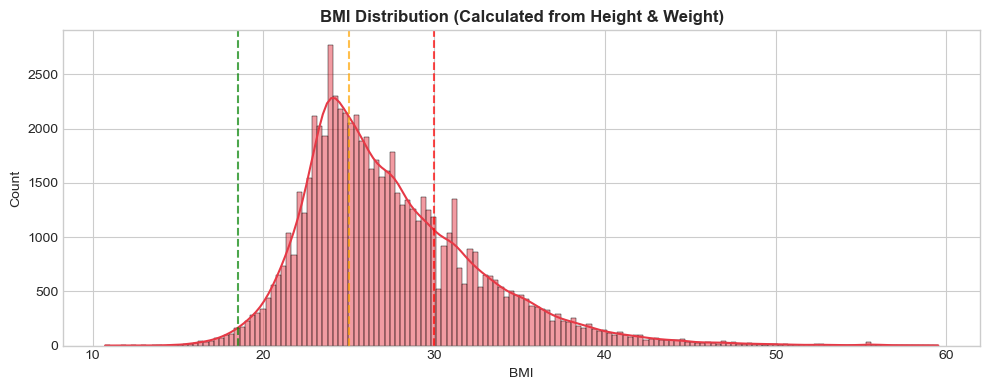


💡 RECOMMENDATION: Create BMI feature during preprocessing (Week 3)


In [9]:
# ============================================================================
# FEATURE ENGINEERING PREVIEW: BMI CALCULATION
# ============================================================================

print("📏 BMI ANALYSIS (Can be derived from height & weight)")
print("=" * 50)

# Calculate BMI: weight(kg) / height(m)^2
bmi = df['weight'] / ((df['height'] / 100) ** 2)

print(f"\nCalculated BMI Statistics:")
print(f"   Min: {bmi.min():.1f}")
print(f"   Max: {bmi.max():.1f}")
print(f"   Mean: {bmi.mean():.1f}")
print(f"   Median: {bmi.median():.1f}")

# BMI Categories
print(f"\n📊 BMI Categories:")
print(f"   Underweight (<18.5): {(bmi < 18.5).sum():,} ({(bmi < 18.5).mean()*100:.1f}%)")
print(f"   Normal (18.5-25): {((bmi >= 18.5) & (bmi < 25)).sum():,} ({((bmi >= 18.5) & (bmi < 25)).mean()*100:.1f}%)")
print(f"   Overweight (25-30): {((bmi >= 25) & (bmi < 30)).sum():,} ({((bmi >= 25) & (bmi < 30)).mean()*100:.1f}%)")
print(f"   Obese (≥30): {(bmi >= 30).sum():,} ({(bmi >= 30).mean()*100:.1f}%)")

# Plot BMI distribution
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(bmi[(bmi > 10) & (bmi < 60)], kde=True, color=COLORS['heart'], ax=ax)  # Filter extreme values for visualization
ax.axvline(18.5, color='green', linestyle='--', alpha=0.7)
ax.axvline(25, color='orange', linestyle='--', alpha=0.7)
ax.axvline(30, color='red', linestyle='--', alpha=0.7)
ax.set_xlabel('BMI')
ax.set_ylabel('Count')
ax.set_title('BMI Distribution (Calculated from Height & Weight)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 RECOMMENDATION: Create BMI feature during preprocessing (Week 3)")

## 4. Statistical Summary

In [10]:
# ============================================================================
# COMPREHENSIVE STATISTICAL SUMMARY
# ============================================================================

stats = statistical_summary(df)
stats


📈 STATISTICAL SUMMARY
📊 Numeric Features: 13
⚠️  Highly Skewed Features (|skew| > 1): 8


,Count,Mean,Std,Min,Q1 (25%),Median,Q3 (75%),Max,Skewness,Kurtosis,IQR
id,70000,49972.420,28851.302,0.000,25006.750,50001.500,74889.250,99999.000,-0.001,-1.198,49882.500
age,70000,19468.866,2467.252,10798.000,17664.000,19703.000,21327.000,23713.000,-0.307,-0.823,3663.000
gender,70000,1.350,0.477,1.000,1.000,1.000,2.000,2.000,0.631,-1.602,1.000
height,70000,164.359,8.210,55.000,159.000,165.000,170.000,250.000,-0.642,7.944,11.000
weight,70000,74.206,14.396,10.000,65.000,72.000,82.000,200.000,1.012,2.587,17.000
ap_hi,70000,128.817,154.011,-150.000,120.000,120.000,140.000,16020.000,85.296,7580.075,20.000
ap_lo,70000,96.630,188.473,-70.000,80.000,80.000,90.000,11000.000,32.114,1425.915,10.000
cholesterol,70000,1.367,0.680,1.000,1.000,1.000,2.000,3.000,1.587,0.994,1.000
gluc,70000,1.226,0.572,1.000,1.000,1.000,1.000,3.000,2.397,4.294,0.000
smoke,70000,0.088,0.283,0.000,0.000,0.000,0.000,1.000,2.906,6.444,0.000


In [11]:
# ============================================================================
# BLOOD PRESSURE ANALYSIS (CRITICAL FOR HEART DISEASE)
# ============================================================================

print("🩺 BLOOD PRESSURE ANALYSIS")
print("=" * 50)

# Normal ranges: Systolic 90-120, Diastolic 60-80
print("\nSystolic BP (ap_hi):")
print(f"   Min: {df['ap_hi'].min()} mmHg")
print(f"   Max: {df['ap_hi'].max()} mmHg")
print(f"   Mean: {df['ap_hi'].mean():.1f} mmHg")

print("\nDiastolic BP (ap_lo):")
print(f"   Min: {df['ap_lo'].min()} mmHg")
print(f"   Max: {df['ap_lo'].max()} mmHg")
print(f"   Mean: {df['ap_lo'].mean():.1f} mmHg")

# Check for unrealistic values
unrealistic_systolic = ((df['ap_hi'] < 50) | (df['ap_hi'] > 250)).sum()
unrealistic_diastolic = ((df['ap_lo'] < 30) | (df['ap_lo'] > 200)).sum()
negative_bp = ((df['ap_hi'] < 0) | (df['ap_lo'] < 0)).sum()

print(f"\n⚠️ DATA QUALITY ISSUES:")
print(f"   Unrealistic Systolic (<50 or >250): {unrealistic_systolic:,} records")
print(f"   Unrealistic Diastolic (<30 or >200): {unrealistic_diastolic:,} records")
print(f"   Negative BP values: {negative_bp:,} records")

# Systolic should be > Diastolic
bp_anomaly = (df['ap_lo'] >= df['ap_hi']).sum()
print(f"   Diastolic ≥ Systolic (impossible): {bp_anomaly:,} records")

print("\n💡 RECOMMENDATION: Remove or cap unrealistic BP values during preprocessing")

🩺 BLOOD PRESSURE ANALYSIS

Systolic BP (ap_hi):
   Min: -150 mmHg
   Max: 16020 mmHg
   Mean: 128.8 mmHg

Diastolic BP (ap_lo):
   Min: -70 mmHg
   Max: 11000 mmHg
   Mean: 96.6 mmHg

⚠️ DATA QUALITY ISSUES:
   Unrealistic Systolic (<50 or >250): 228 records
   Unrealistic Diastolic (<30 or >200): 1,006 records
   Negative BP values: 8 records
   Diastolic ≥ Systolic (impossible): 1,236 records

💡 RECOMMENDATION: Remove or cap unrealistic BP values during preprocessing


## 5. Target Variable Analysis


⚖️ CLASS DISTRIBUTION ANALYSIS
🎯 Target Column: cardio
📊 Number of Classes: 2

📈 Class Distribution:
   • Class 0: 35,021 samples (50.03%)
   • Class 1: 34,979 samples (49.97%)

⚖️ Imbalance Ratio: 1.00:1
✅ Classes are relatively balanced.


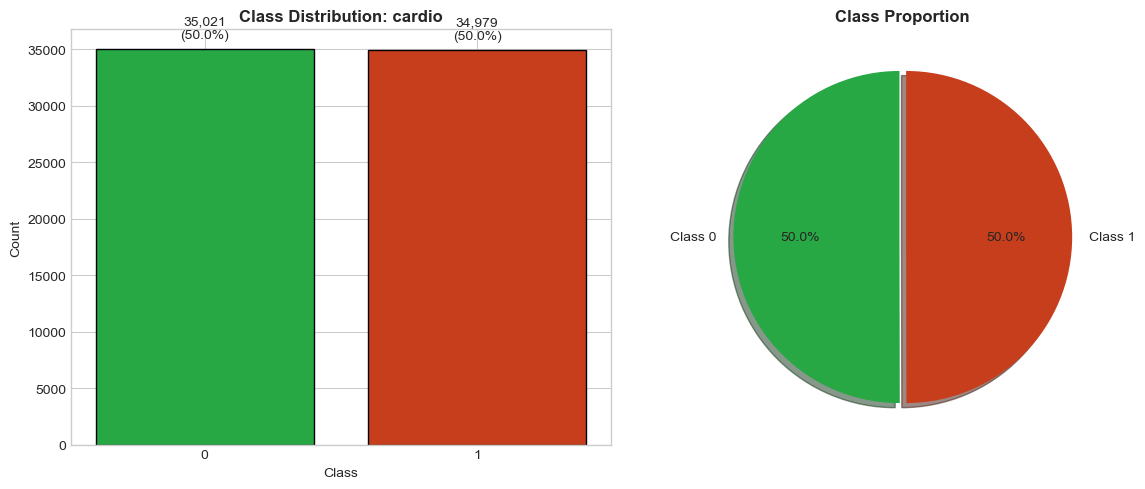


📁 Figure saved to: figures\heart_disease\class_distribution.png


<Figure size 640x480 with 0 Axes>

In [12]:
# ============================================================================
# CLASS DISTRIBUTION (TARGET: cardio)
# ============================================================================

class_info = class_distribution_analysis(df, target_col='cardio', figsize=(12, 5))

# Save figure
plt.savefig(FIGURES_PATH / 'class_distribution.png', dpi=150, bbox_inches='tight', facecolor='white')
print(f"\n📁 Figure saved to: {FIGURES_PATH / 'class_distribution.png'}")

## 6. Feature Type Analysis

In [13]:
# ============================================================================
# CATEGORIZE FEATURES BY TYPE
# ============================================================================

feature_types = feature_type_analysis(df)


📋 FEATURE TYPE ANALYSIS

📌 CONTINUOUS (6 features):
   id, age, height, weight, ap_hi, ap_lo

📌 DISCRETE (2 features):
   cholesterol, gluc

📌 BINARY (5 features):
   gender, smoke, alco, active, cardio



📊 CATEGORICAL/ORDINAL FEATURE DISTRIBUTIONS


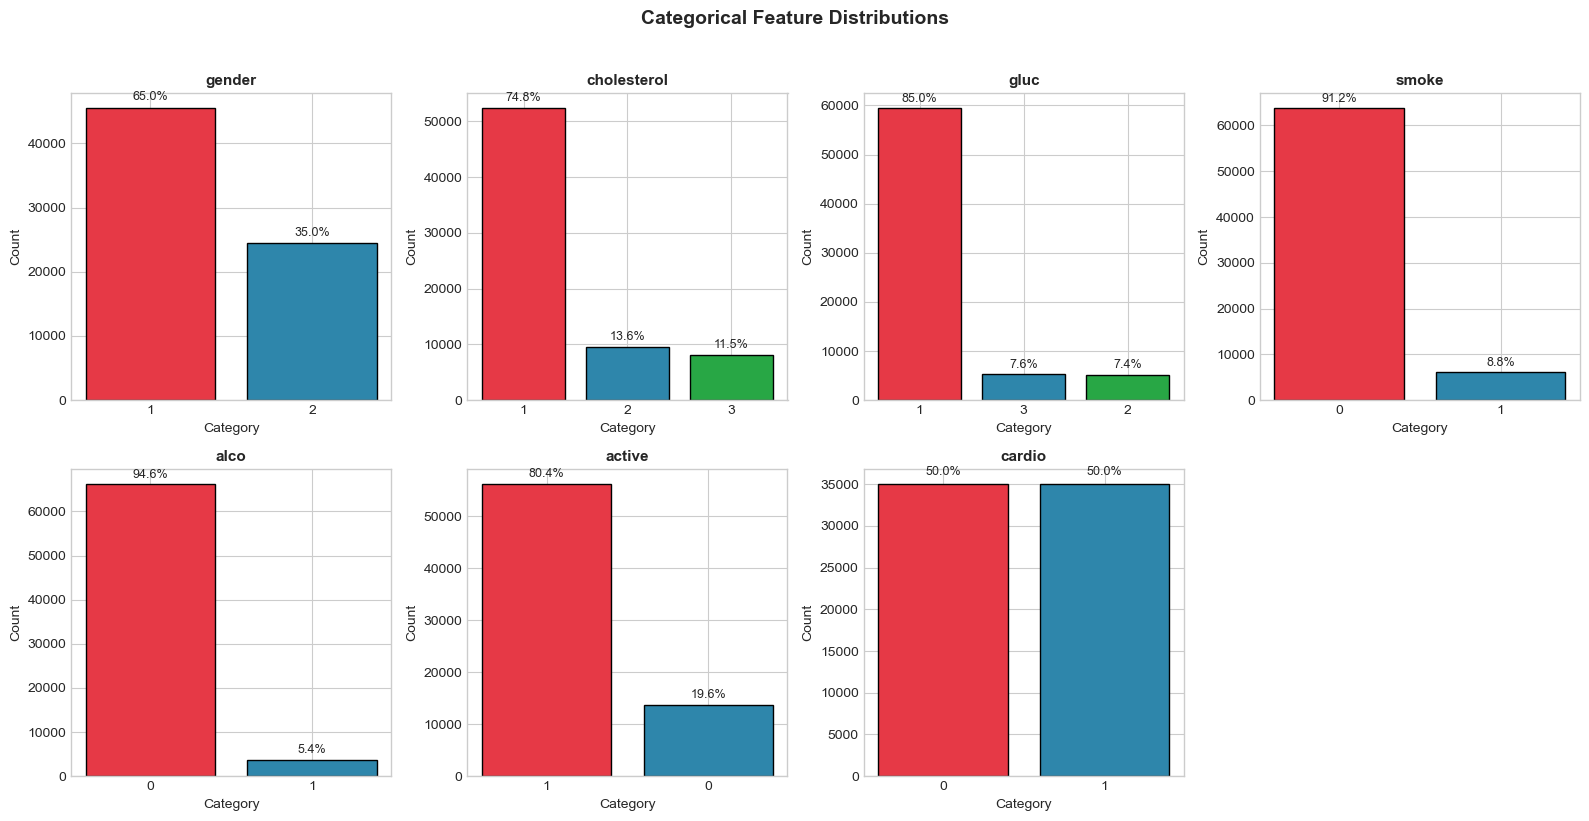


📁 Figure saved to: figures\heart_disease\categorical_distributions.png


In [14]:
# ============================================================================
# CATEGORICAL FEATURE ANALYSIS
# ============================================================================

print("📊 CATEGORICAL/ORDINAL FEATURE DISTRIBUTIONS")
print("=" * 60)

categorical_cols = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
    ax = axes[idx]
    value_counts = df[col].value_counts()
    colors = [COLORS['heart'], COLORS['primary'], COLORS['success']]
    
    bars = ax.bar(value_counts.index.astype(str), value_counts.values, 
                  color=colors[:len(value_counts)], edgecolor='black')
    ax.set_title(f'{col}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Category')
    ax.set_ylabel('Count')
    
    # Add percentage labels
    total = len(df)
    for bar, count in zip(bars, value_counts.values):
        pct = count / total * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total*0.01,
               f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

# Hide the last empty subplot
axes[-1].set_visible(False)

plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'categorical_distributions.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n📁 Figure saved to: {FIGURES_PATH / 'categorical_distributions.png'}")

## 7. Continuous Feature Distributions


📊 FEATURE DISTRIBUTIONS


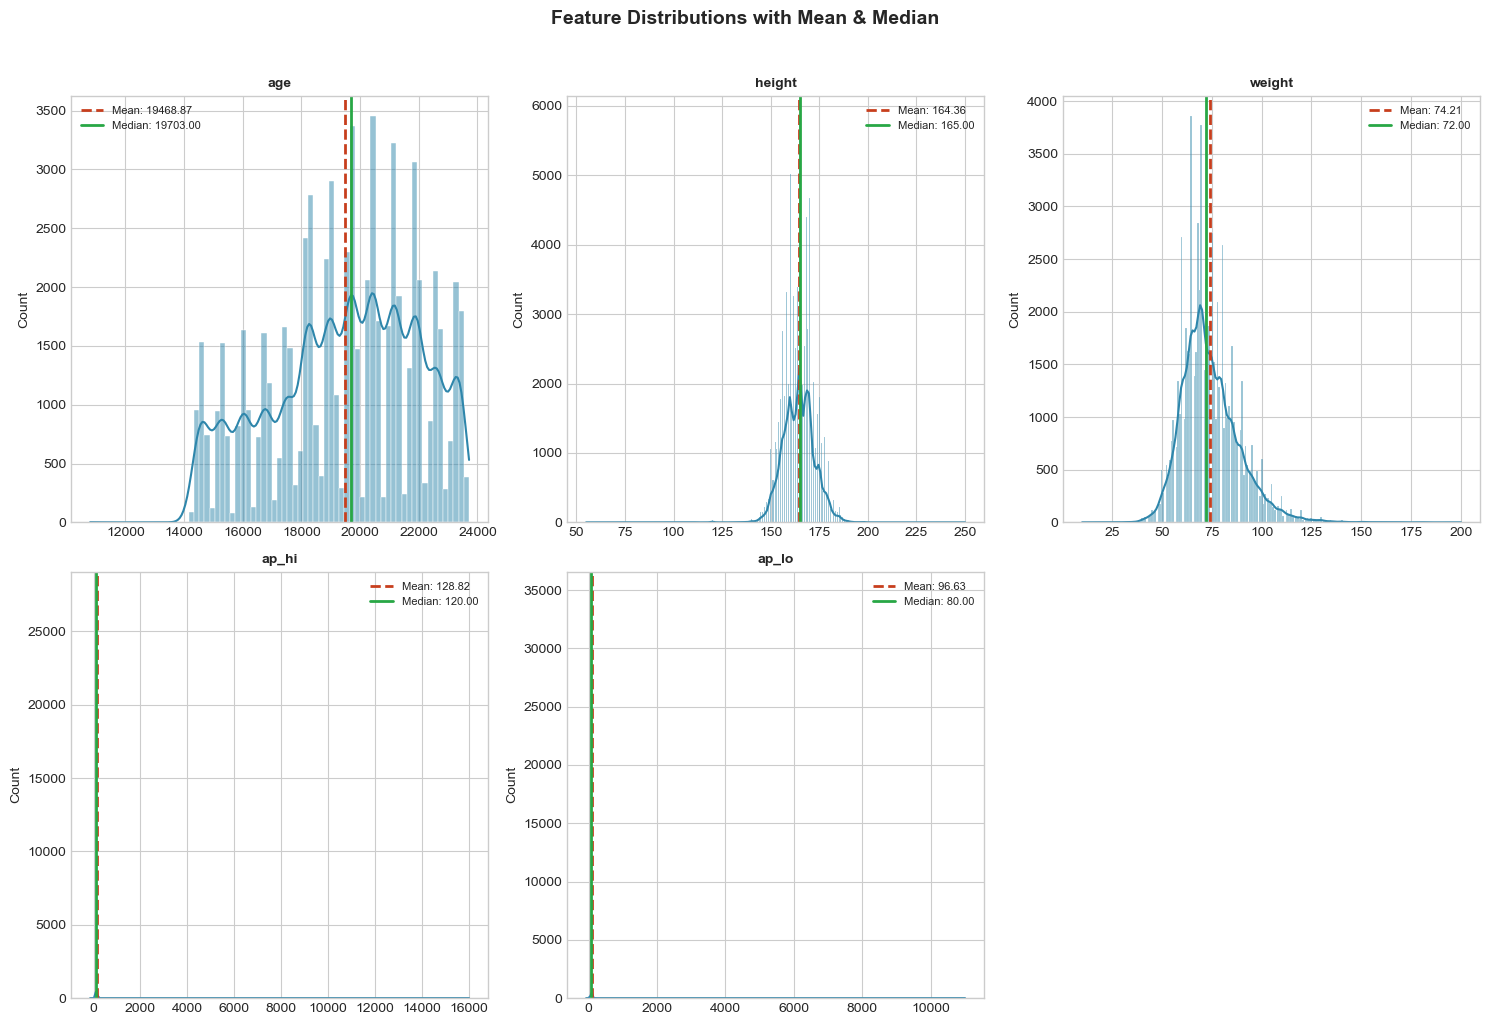


📁 Figure saved to: figures\heart_disease\continuous_distributions.png


<Figure size 640x480 with 0 Axes>

In [15]:
# ============================================================================
# CONTINUOUS FEATURE DISTRIBUTIONS
# ============================================================================

continuous_cols = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']

distribution_plots(df, columns=continuous_cols, n_cols=3, figsize=(15, 10))

plt.savefig(FIGURES_PATH / 'continuous_distributions.png', dpi=150, bbox_inches='tight', facecolor='white')
print(f"\n📁 Figure saved to: {FIGURES_PATH / 'continuous_distributions.png'}")

## 8. Outlier Detection


🔎 OUTLIER ANALYSIS (Method: IQR)
📊 Columns Analyzed: 5
⚠️  Total Outliers Detected: 8,409
🔴 Columns with >5% Outliers: 1


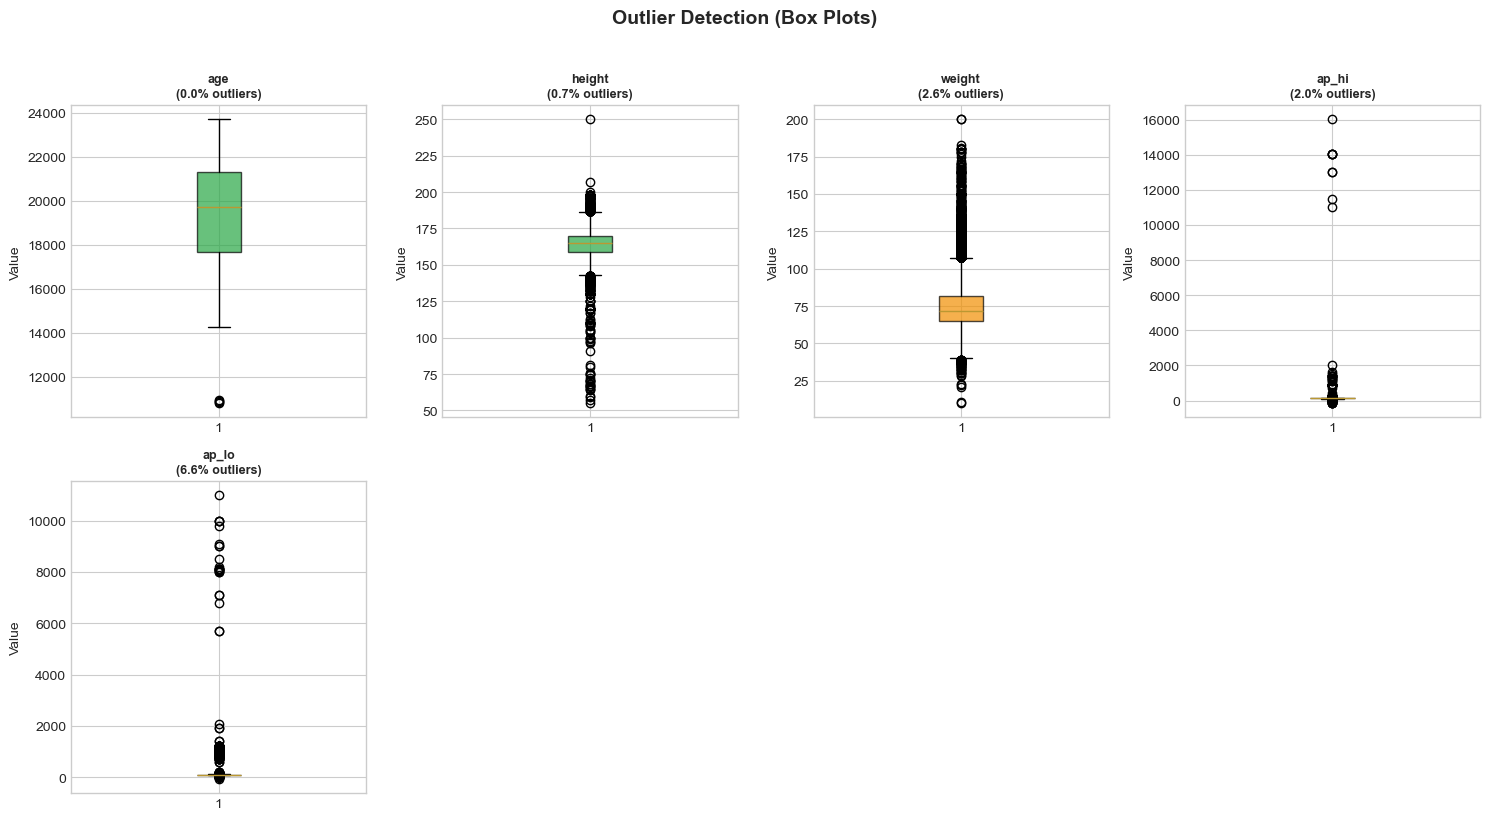


📁 Figure saved to: figures\heart_disease\outliers_boxplot.png

📋 Outlier Summary:


,Column,Outlier_Count,Outlier_Percentage,Lower_Bound,Upper_Bound,Min,Max
4,ap_lo,4632,6.620,65.000,105.000,-70.000,11000.000
2,weight,1819,2.600,39.500,107.500,10.000,200.000
3,ap_hi,1435,2.050,90.000,170.000,-150.000,16020.000
1,height,519,0.740,142.500,186.500,55.000,250.000
0,age,4,0.010,12169.500,26821.500,10798.000,23713.000


<Figure size 640x480 with 0 Axes>

In [16]:
# ============================================================================
# OUTLIER ANALYSIS
# ============================================================================

outlier_stats = outlier_analysis(df, columns=['age', 'height', 'weight', 'ap_hi', 'ap_lo'],
                                  method='iqr', threshold=1.5, figsize=(15, 8))

plt.savefig(FIGURES_PATH / 'outliers_boxplot.png', dpi=150, bbox_inches='tight', facecolor='white')
print(f"\n📁 Figure saved to: {FIGURES_PATH / 'outliers_boxplot.png'}")

# Display outlier summary
print("\n📋 Outlier Summary:")
outlier_stats

🔍 BLOOD PRESSURE OUTLIER INVESTIGATION


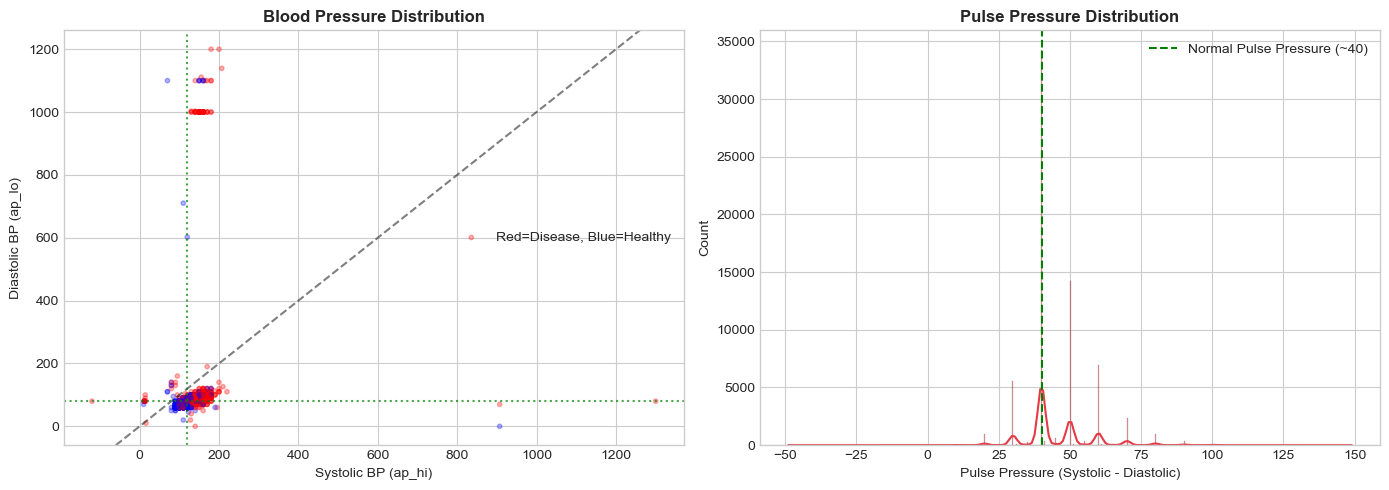


📊 Pulse Pressure Statistics:
   Normal range: 30-50 mmHg
   Our data mean: 32.2 mmHg
   Negative pulse pressure (impossible): 1,234 records


In [17]:
# ============================================================================
# DETAILED OUTLIER INVESTIGATION: BLOOD PRESSURE
# ============================================================================

print("🔍 BLOOD PRESSURE OUTLIER INVESTIGATION")
print("=" * 60)

# Visualize blood pressure anomalies
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot of systolic vs diastolic
ax1 = axes[0]
# Sample for visualization (full dataset too large)
sample = df.sample(n=min(5000, len(df)), random_state=42)
colors = ['red' if c == 1 else 'blue' for c in sample['cardio']]
ax1.scatter(sample['ap_hi'], sample['ap_lo'], c=colors, alpha=0.3, s=10)
ax1.set_xlabel('Systolic BP (ap_hi)')
ax1.set_ylabel('Diastolic BP (ap_lo)')
ax1.set_title('Blood Pressure Distribution', fontsize=12, fontweight='bold')
ax1.axline((0, 0), slope=1, color='black', linestyle='--', alpha=0.5, label='ap_hi = ap_lo')

# Add reference lines for normal ranges
ax1.axvline(120, color='green', linestyle=':', alpha=0.7)
ax1.axhline(80, color='green', linestyle=':', alpha=0.7)
ax1.legend(['Red=Disease, Blue=Healthy'])

# Histogram of BP difference
ax2 = axes[1]
bp_diff = df['ap_hi'] - df['ap_lo']
sns.histplot(bp_diff[(bp_diff > -50) & (bp_diff < 150)], kde=True, color=COLORS['heart'], ax=ax2)
ax2.axvline(40, color='green', linestyle='--', label='Normal Pulse Pressure (~40)')
ax2.set_xlabel('Pulse Pressure (Systolic - Diastolic)')
ax2.set_ylabel('Count')
ax2.set_title('Pulse Pressure Distribution', fontsize=12, fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'blood_pressure_analysis.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Statistics on anomalies
print(f"\n📊 Pulse Pressure Statistics:")
print(f"   Normal range: 30-50 mmHg")
print(f"   Our data mean: {bp_diff.mean():.1f} mmHg")
print(f"   Negative pulse pressure (impossible): {(bp_diff < 0).sum():,} records")

## 9. Correlation Analysis


🔗 CORRELATION ANALYSIS (Method: PEARSON)
✅ No highly correlated feature pairs found.

🎯 Top 5 Features Correlated with cardio:
   • age: +0.238
   • cholesterol: +0.221
   • weight: +0.182
   • gluc: +0.089
   • ap_lo: +0.066


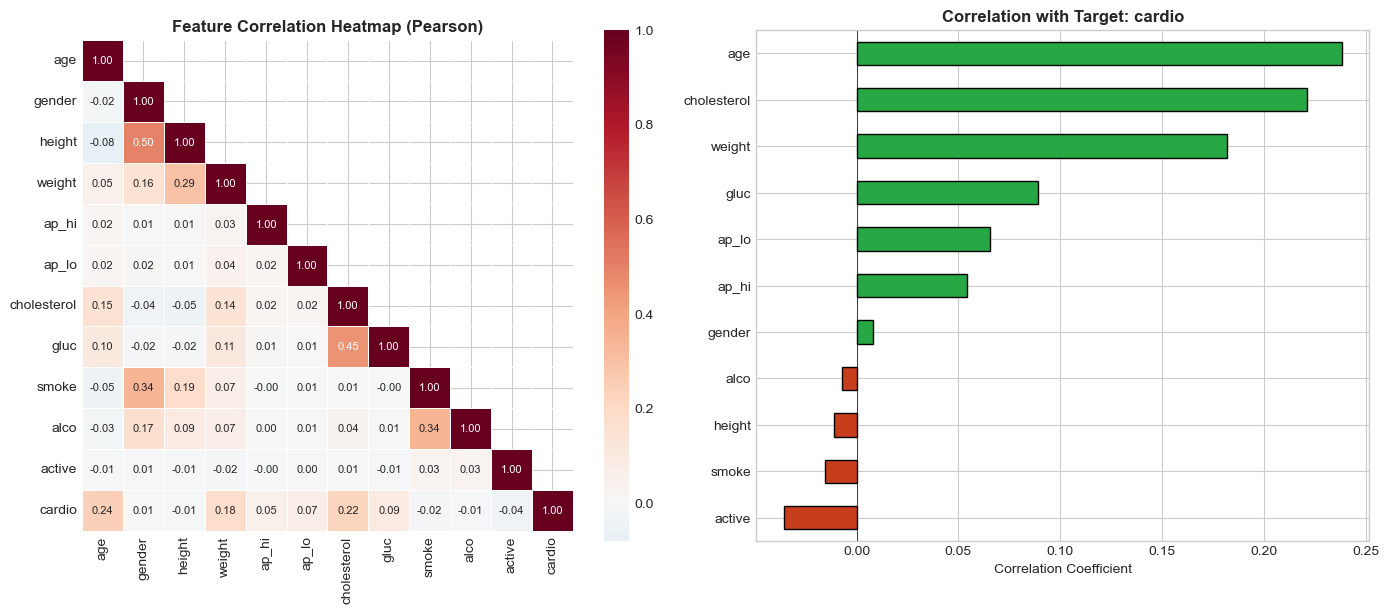


📁 Figure saved to: figures\heart_disease\correlation_heatmap.png


<Figure size 640x480 with 0 Axes>

In [18]:
# ============================================================================
# CORRELATION ANALYSIS
# ============================================================================

# Exclude ID column for correlation
df_corr = df.drop('id', axis=1)

corr_matrix = correlation_analysis(df_corr, target_col='cardio', method='pearson', figsize=(14, 6))

plt.savefig(FIGURES_PATH / 'correlation_heatmap.png', dpi=150, bbox_inches='tight', facecolor='white')
print(f"\n📁 Figure saved to: {FIGURES_PATH / 'correlation_heatmap.png'}")

🎯 FEATURE IMPORTANCE PREVIEW (Correlation-based)


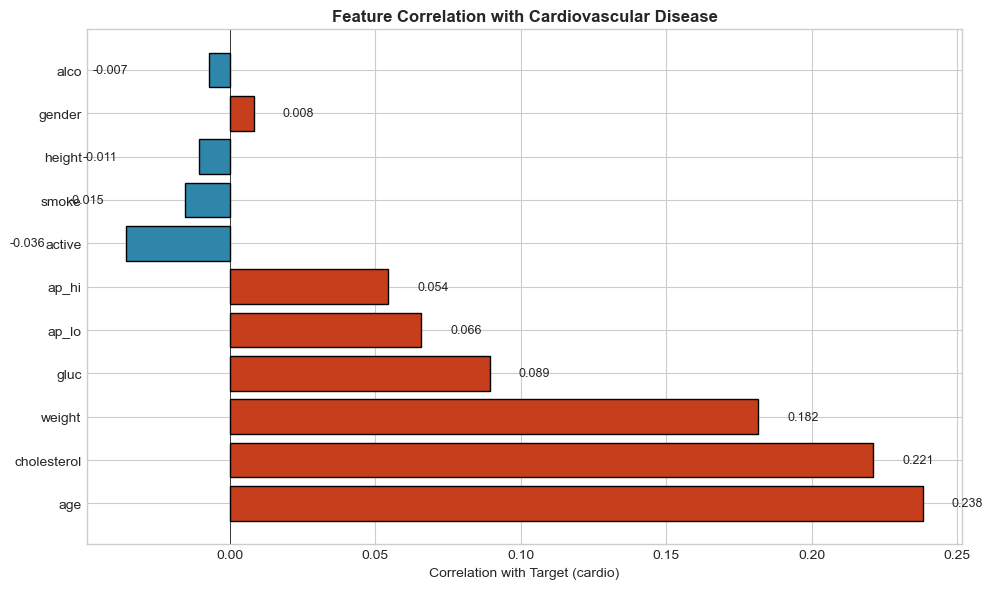


📊 Top Features Correlated with Heart Disease:
   ↑ age: 0.2382
   ↑ cholesterol: 0.2211
   ↑ weight: 0.1817
   ↑ gluc: 0.0893
   ↑ ap_lo: 0.0657
   ↑ ap_hi: 0.0545
   ↓ active: -0.0357
   ↓ smoke: -0.0155
   ↓ height: -0.0108
   ↑ gender: 0.0081
   ↓ alco: -0.0073


In [19]:
# ============================================================================
# FEATURE IMPORTANCE PREVIEW (Based on Correlation with Target)
# ============================================================================

print("🎯 FEATURE IMPORTANCE PREVIEW (Correlation-based)")
print("=" * 60)

target_correlations = corr_matrix['cardio'].drop('cardio').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = [COLORS['danger'] if c > 0 else COLORS['primary'] for c in target_correlations.values]
bars = ax.barh(target_correlations.index, target_correlations.values, color=colors, edgecolor='black')
ax.set_xlabel('Correlation with Target (cardio)')
ax.set_title('Feature Correlation with Cardiovascular Disease', fontsize=12, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.5)

# Add correlation values on bars
for bar, corr in zip(bars, target_correlations.values):
    x_pos = corr + 0.01 if corr > 0 else corr - 0.04
    ax.text(x_pos, bar.get_y() + bar.get_height()/2, f'{corr:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'feature_importance_correlation.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("\n📊 Top Features Correlated with Heart Disease:")
for feat, corr in target_correlations.items():
    direction = "↑" if corr > 0 else "↓"
    print(f"   {direction} {feat}: {corr:.4f}")

## 10. Feature vs Target Analysis

📊 FEATURE DISTRIBUTIONS BY HEART DISEASE STATUS


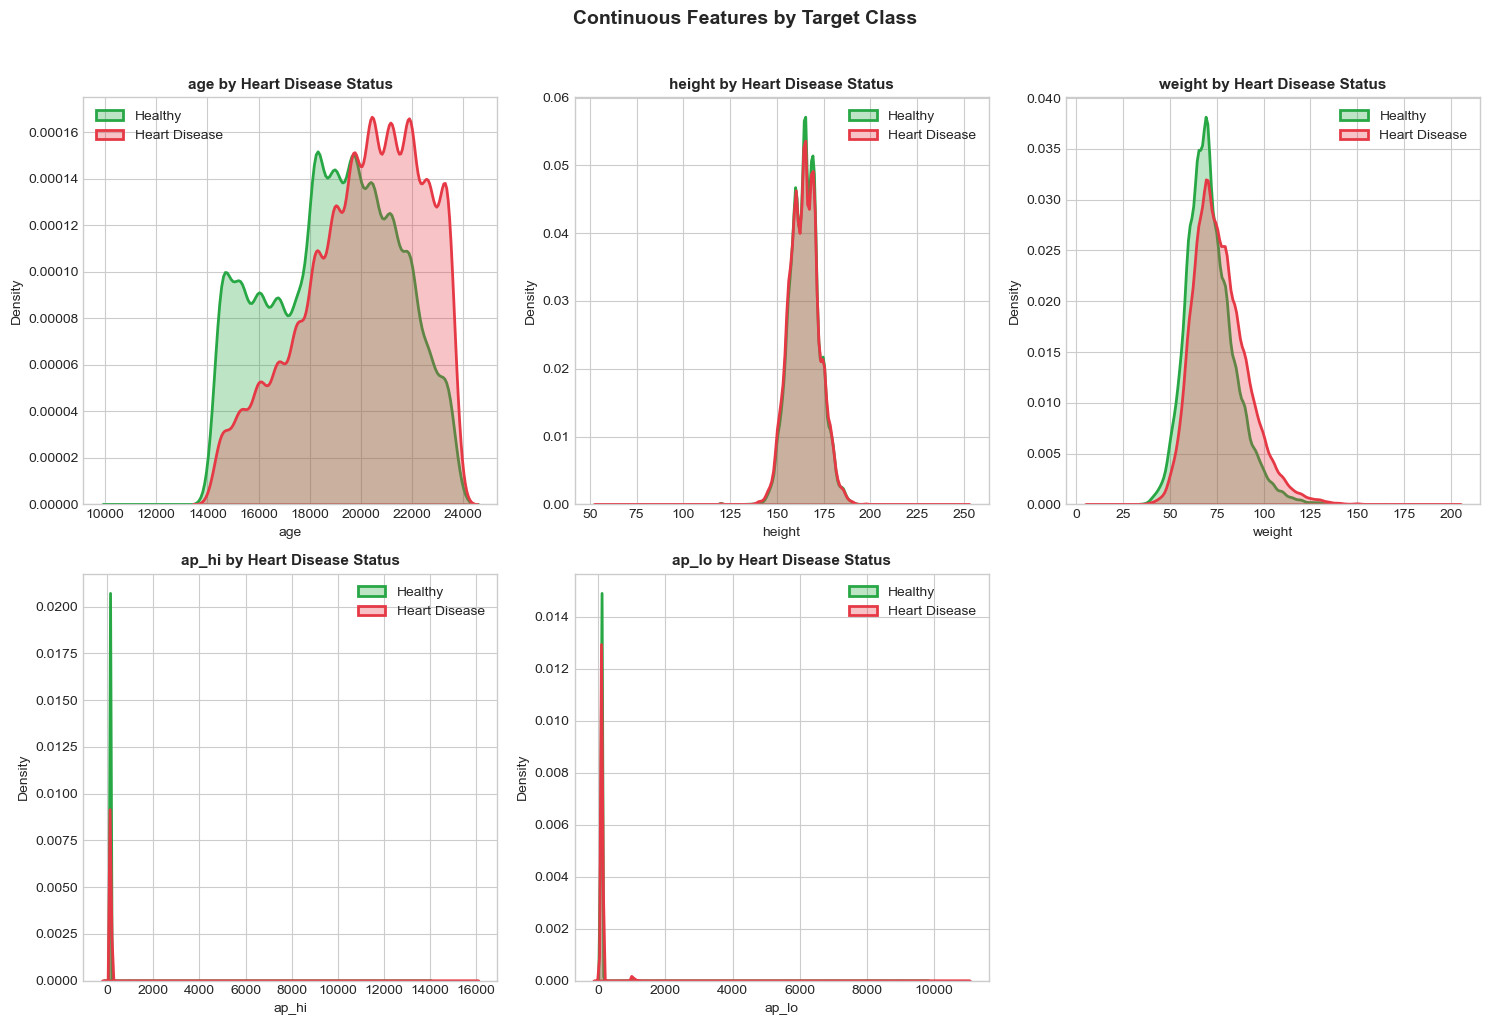


📁 Figure saved to: figures\heart_disease\features_by_target.png


In [20]:
# ============================================================================
# FEATURE DISTRIBUTIONS BY TARGET CLASS
# ============================================================================

print("📊 FEATURE DISTRIBUTIONS BY HEART DISEASE STATUS")
print("=" * 60)

continuous_cols = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(continuous_cols):
    ax = axes[idx]
    
    # Plot distributions for each class
    for cardio_val, label, color in [(0, 'Healthy', COLORS['success']), (1, 'Heart Disease', COLORS['heart'])]:
        data = df[df['cardio'] == cardio_val][col]
        sns.kdeplot(data, ax=ax, label=label, color=color, linewidth=2, fill=True, alpha=0.3)
    
    ax.set_title(f'{col} by Heart Disease Status', fontsize=11, fontweight='bold')
    ax.set_xlabel(col)
    ax.legend()

# Hide empty subplot
axes[-1].set_visible(False)

plt.suptitle('Continuous Features by Target Class', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'features_by_target.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n📁 Figure saved to: {FIGURES_PATH / 'features_by_target.png'}")

📊 CATEGORICAL FEATURES VS HEART DISEASE


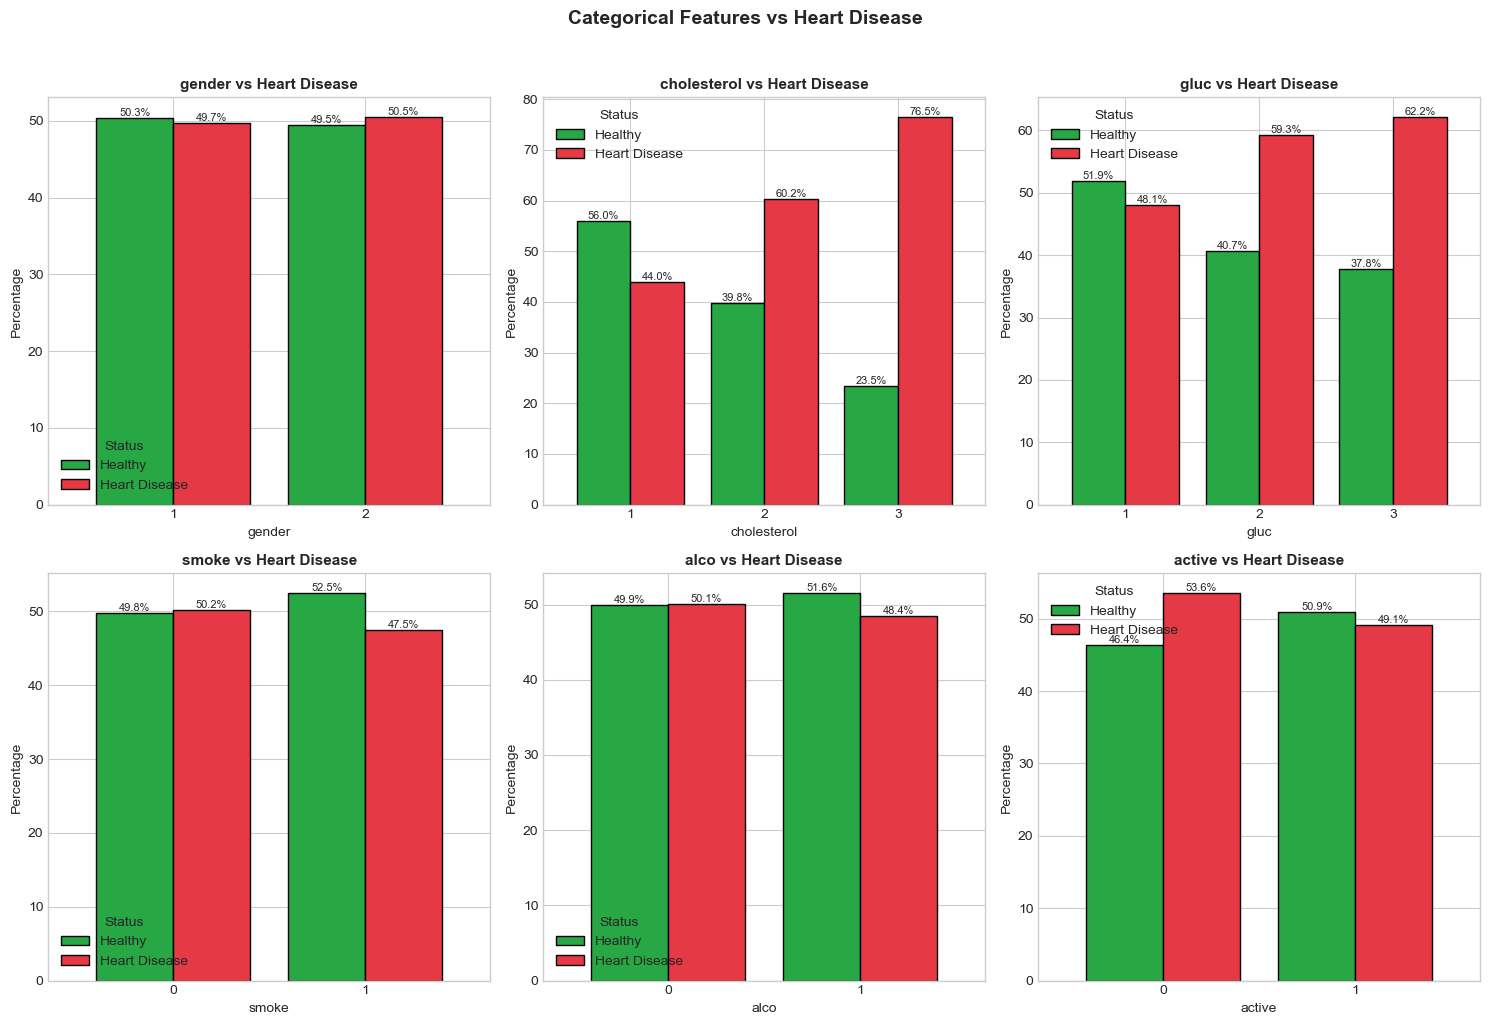


📁 Figure saved to: figures\heart_disease\categorical_vs_target.png


In [21]:
# ============================================================================
# CATEGORICAL FEATURES VS TARGET (Chi-square test preview)
# ============================================================================

print("📊 CATEGORICAL FEATURES VS HEART DISEASE")
print("=" * 60)

categorical_cols = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
    ax = axes[idx]
    
    # Create cross-tabulation
    crosstab = pd.crosstab(df[col], df['cardio'], normalize='index') * 100
    
    crosstab.plot(kind='bar', ax=ax, color=[COLORS['success'], COLORS['heart']], 
                  edgecolor='black', width=0.8)
    ax.set_title(f'{col} vs Heart Disease', fontsize=11, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Percentage')
    ax.legend(['Healthy', 'Heart Disease'], title='Status')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    
    # Add percentage labels
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', fontsize=8)

plt.suptitle('Categorical Features vs Heart Disease', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'categorical_vs_target.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n📁 Figure saved to: {FIGURES_PATH / 'categorical_vs_target.png'}")

## 11. Summary & Preprocessing Recommendations

In [22]:
# ============================================================================
# EDA SUMMARY
# ============================================================================

print("\n")
print("╔" + "═" * 68 + "╗")
print("║" + "  ❤️ HEART DISEASE DATASET - EDA SUMMARY".ljust(67) + "║")
print("╚" + "═" * 68 + "╝")

print("\n📊 DATASET OVERVIEW:")
print(f"   • Total Records: {len(df):,}")
print(f"   • Total Features: {len(df.columns)} (including target)")
print(f"   • Target Column: 'cardio' (0=Healthy, 1=Disease)")
print(f"   • Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n✅ DATA QUALITY FINDINGS:")
print(f"   • Missing Values: {df.isnull().sum().sum()} (0%)")
print(f"   • Duplicate Records: {df.drop('id', axis=1).duplicated().sum():,}")
print(f"   • Class Balance: {df['cardio'].value_counts(normalize=True)[0]*100:.1f}% / {df['cardio'].value_counts(normalize=True)[1]*100:.1f}%")

print("\n⚠️ DATA ISSUES IDENTIFIED:")
print(f"   • Age stored in DAYS (needs conversion to years)")
print(f"   • Unrealistic blood pressure values present")
print(f"   • {(df['ap_lo'] >= df['ap_hi']).sum():,} records with diastolic ≥ systolic")
print(f"   • Outliers in height, weight, blood pressure")

print("\n📈 KEY INSIGHTS:")
print(f"   • Age range: {df['age'].min()/365:.0f} - {df['age'].max()/365:.0f} years")
print(f"   • Strong predictors: age, cholesterol, ap_hi, ap_lo, weight")
print(f"   • Weak predictors: smoke, alco (surprising!)")
print(f"   • BMI can be derived from height/weight")



╔════════════════════════════════════════════════════════════════════╗
║  ❤️ HEART DISEASE DATASET - EDA SUMMARY                           ║
╚════════════════════════════════════════════════════════════════════╝

📊 DATASET OVERVIEW:
   • Total Records: 70,000
   • Total Features: 13 (including target)
   • Target Column: 'cardio' (0=Healthy, 1=Disease)
   • Memory Usage: 6.94 MB

✅ DATA QUALITY FINDINGS:
   • Missing Values: 0 (0%)
   • Duplicate Records: 24
   • Class Balance: 50.0% / 50.0%

⚠️ DATA ISSUES IDENTIFIED:
   • Age stored in DAYS (needs conversion to years)
   • Unrealistic blood pressure values present
   • 1,236 records with diastolic ≥ systolic
   • Outliers in height, weight, blood pressure

📈 KEY INSIGHTS:
   • Age range: 30 - 65 years
   • Strong predictors: age, cholesterol, ap_hi, ap_lo, weight
   • Weak predictors: smoke, alco (surprising!)
   • BMI can be derived from height/weight


In [23]:
# ============================================================================
# PREPROCESSING RECOMMENDATIONS FOR WEEK 3
# ============================================================================

print("\n")
print("╔" + "═" * 68 + "╗")
print("║" + "  🔧 PREPROCESSING RECOMMENDATIONS (Week 3)".ljust(67) + "║")
print("╚" + "═" * 68 + "╝")

recommendations = """
1. FEATURE ENGINEERING:
   ✓ Convert 'age' from days to years
   ✓ Create 'bmi' from height and weight
   ✓ Create 'pulse_pressure' = ap_hi - ap_lo
   ✓ Create age groups (young, middle, senior)

2. DATA CLEANING:
   ✓ Remove records with negative blood pressure
   ✓ Remove records where diastolic ≥ systolic
   ✓ Cap or remove extreme outliers:
     - Height: reasonable range 100-220 cm
     - Weight: reasonable range 30-200 kg  
     - Systolic BP: reasonable range 70-250 mmHg
     - Diastolic BP: reasonable range 40-150 mmHg

3. FEATURE SCALING:
   ✓ StandardScaler for continuous features
   ✓ Keep binary/ordinal features as-is

4. ENCODING:
   ✓ Gender: already numeric (1, 2) → convert to (0, 1)
   ✓ Cholesterol & Glucose: ordinal → keep as-is or one-hot

5. CLASS BALANCE:
   ✓ Classes are nearly balanced (50/50) → No SMOTE needed

6. SCHEMA ALIGNMENT (for unified dataset):
   ✓ Common features: age, gender, bmi, bp_systolic, bp_diastolic, cholesterol
   ✓ Map to unified naming convention
"""

print(recommendations)



╔════════════════════════════════════════════════════════════════════╗
║  🔧 PREPROCESSING RECOMMENDATIONS (Week 3)                         ║
╚════════════════════════════════════════════════════════════════════╝

1. FEATURE ENGINEERING:
   ✓ Convert 'age' from days to years
   ✓ Create 'bmi' from height and weight
   ✓ Create 'pulse_pressure' = ap_hi - ap_lo
   ✓ Create age groups (young, middle, senior)

2. DATA CLEANING:
   ✓ Remove records with negative blood pressure
   ✓ Remove records where diastolic ≥ systolic
   ✓ Cap or remove extreme outliers:
     - Height: reasonable range 100-220 cm
     - Weight: reasonable range 30-200 kg  
     - Systolic BP: reasonable range 70-250 mmHg
     - Diastolic BP: reasonable range 40-150 mmHg

3. FEATURE SCALING:
   ✓ StandardScaler for continuous features
   ✓ Keep binary/ordinal features as-is

4. ENCODING:
   ✓ Gender: already numeric (1, 2) → convert to (0, 1)
   ✓ Cholesterol & Glucose: ordinal → keep as-is or one-hot

5. CLASS BALANCE

In [24]:
# ============================================================================
# SAVE EDA SUMMARY TO FILE
# ============================================================================

summary_dict = {
    'dataset': 'Heart Disease (Cardiovascular)',
    'rows': len(df),
    'columns': len(df.columns),
    'target_column': 'cardio',
    'missing_values': 0,
    'duplicate_records': df.drop('id', axis=1).duplicated().sum(),
    'class_balance': f"{df['cardio'].value_counts(normalize=True)[0]*100:.1f}% / {df['cardio'].value_counts(normalize=True)[1]*100:.1f}%",
    'memory_mb': round(df.memory_usage(deep=True).sum() / 1024**2, 2),
    'top_correlations': target_correlations.head(5).to_dict(),
    'data_quality_issues': [
        'Age in days (needs conversion)',
        'Unrealistic blood pressure values',
        f'{(df["ap_lo"] >= df["ap_hi"]).sum()} records with diastolic >= systolic',
        'Outliers in continuous features'
    ]
}

# Save as JSON for later use
import json
with open(FIGURES_PATH / 'eda_summary.json', 'w') as f:
    json.dump(summary_dict, f, indent=2)

print(f"\n📁 EDA Summary saved to: {FIGURES_PATH / 'eda_summary.json'}")
print("\n✅ Heart Disease EDA Complete!")

TypeError: Object of type int64 is not JSON serializable

---

## 📋 Next Steps

1. **Week 2 Remaining:** Complete EDA for Diabetes, Kidney, and Liver datasets
2. **Week 3:** Implement preprocessing recommendations above
3. **Week 3-4:** Create unified schema for multi-disease fusion

---

**Notebook Complete** | BTP 2025-2026 | IIIT Sri City